# FEM from scratch: 2D Laplace equation with Dirichlet boundary conditions

This notebook implements a small **linear triangular ($P_1$) finite-element solver from scratch** for the Laplace equation on the unit square. It is adapted and pedagogically extended from Steve Runser's [`FEM-from-scratch-python`](https://github.com/SteveRunser/FEM-from-scratch-python) repository.

The goal is not to compete with a production FEM package. Instead, every essential step is made visible:

1. build a triangular mesh;
2. define the $P_1$ basis on the reference triangle;
3. map gradients to each physical element;
4. compute local stiffness matrices;
5. assemble the global sparse stiffness matrix;
6. impose non-homogeneous Dirichlet data;
7. solve the reduced linear system;
8. compare with an analytical solution;
9. perform a mesh-refinement study.

The mathematical background follows standard FEM treatments such as Larson & Bengzon (2013) and Brenner & Scott (2008).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve

## 1. Model problem

We solve

$$
-\Delta u = 0 \qquad \text{in } \Omega=(0,1)^2,
$$

with Dirichlet boundary condition

$$
g(x,y)=
\begin{cases}
\sin(\pi y), & x=1,\\
0, & \text{on the other three sides}.
\end{cases}
$$

This choice is useful because the exact harmonic solution is known:

$$
u_{\rm ex}(x,y)=\frac{\sinh(\pi x)}{\sinh(\pi)}\sin(\pi y).
$$

### Weak form

Define

$$
V_g=\{w\in H^1(\Omega):w|_{\partial\Omega}=g\},
\qquad
V_0=H_0^1(\Omega).
$$

Multiplying by $v\in V_0$ and integrating by parts gives

$$
\int_\Omega \nabla u\cdot\nabla v\,dx=0,
\qquad \forall v\in V_0.
$$

For the standard conforming $P_1$ method, the finite-element approximation is globally continuous and belongs to $H^1(\Omega)$, but it is only **piecewise linear**: global $C^1$ continuity is neither expected nor required.

## 2. Reference triangle and $P_1$ basis

On the reference triangle

$$
\widehat T=\{(\xi,\eta):\xi\ge0,\eta\ge0,\xi+\eta\le1\},
$$

we use

$$
\widehat\phi_1=\xi,\qquad
\widehat\phi_2=\eta,\qquad
\widehat\phi_3=1-\xi-\eta.
$$

Therefore

$$
\widehat\nabla\widehat\phi_1=(1,0)^T,\quad
\widehat\nabla\widehat\phi_2=(0,1)^T,\quad
\widehat\nabla\widehat\phi_3=(-1,-1)^T.
$$

For a physical triangle $T$ with vertices $\mathbf x_1,\mathbf x_2,\mathbf x_3$, use the affine map

$$
\mathbf x=\mathbf x_3+J_T(\xi,\eta)^T,
\qquad
J_T=[\mathbf x_1-\mathbf x_3\;\;\mathbf x_2-\mathbf x_3].
$$

Then

$$
\nabla\phi_i=J_T^{-T}\widehat\nabla\widehat\phi_i,
\qquad
|T|=\frac{|\det J_T|}{2},
$$

and, because the gradients are constant inside a linear triangle,

$$
K^{(T)}_{ij}=\int_T\nabla\phi_i\cdot\nabla\phi_j\,dx
=|T|\,\nabla\phi_i\cdot\nabla\phi_j.
$$

In [2]:
GRAD_REF = np.array([[ 1.0,  0.0],
                     [ 0.0,  1.0],
                     [-1.0, -1.0]])


def element_geometry(xy):
    """Return area and physical gradients of the three P1 basis functions."""
    J = np.column_stack((xy[0] - xy[2], xy[1] - xy[2]))
    detJ = np.linalg.det(J)
    if abs(detJ) < 1e-14:
        raise ValueError("Degenerate triangle")

    area = 0.5 * abs(detJ)
    # With gradients stored as row vectors: grad_x = grad_hat @ J^{-1}.
    grad_phys = GRAD_REF @ np.linalg.inv(J)
    return area, grad_phys


def element_stiffness(xy):
    area, grad_phys = element_geometry(xy)
    return area * (grad_phys @ grad_phys.T)

## 3. A self-contained triangular mesh

The original repository example loads a triangulated square from an external mesh file. 

For teaching, it is convenient to make the notebook completely self-contained, so here the unit square is meshed directly in Python. 

Each Cartesian cell is split into two triangles; an optional small jitter can be applied to interior nodes to make the mesh visibly non-uniform while preserving the boundary.

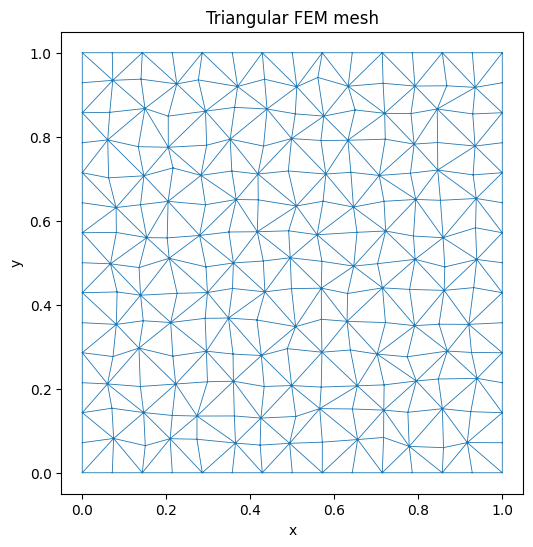

In [3]:
def triangular_mesh(n=16, jitter=0.0, seed=7):
    """Create a conforming triangular mesh of [0,1]^2.

    Parameters
    ----------
    n : int
        Number of square cells along each coordinate direction.
    jitter : float
        Interior-node perturbation as a fraction of h=1/n. Keep <~0.25.
    seed : int
        RNG seed for reproducibility.
    """
    x = np.linspace(0.0, 1.0, n + 1)
    X, Y = np.meshgrid(x, x, indexing="xy")
    nodes = np.column_stack([X.ravel(), Y.ravel()])

    if jitter > 0:
        rng = np.random.default_rng(seed)
        h = 1.0 / n
        px, py = nodes[:, 0], nodes[:, 1]
        interior = ((px > 0) & (px < 1) & (py > 0) & (py < 1))
        nodes[interior] += rng.uniform(
            -jitter * h, jitter * h, size=(interior.sum(), 2)
        )

    triangles = []
    for j in range(n):
        for i in range(n):
            n00 = j * (n + 1) + i
            n10 = n00 + 1
            n01 = n00 + (n + 1)
            n11 = n01 + 1
            # Alternate the diagonal to avoid a directional visual bias.
            if (i + j) % 2 == 0:
                triangles += [[n00, n10, n11], [n00, n11, n01]]
            else:
                triangles += [[n00, n10, n01], [n10, n11, n01]]

    triangles = np.asarray(triangles, dtype=int)

    # Safety check: no inverted/degenerate elements after jittering.
    for tri in triangles:
        area, _ = element_geometry(nodes[tri])
        if area <= 1e-14:
            raise ValueError("Invalid mesh element")

    return nodes, triangles


nodes, triangles = triangular_mesh(n=14, jitter=0.18)

plt.figure(figsize=(6, 6))
plt.triplot(nodes[:, 0], nodes[:, 1], triangles, linewidth=0.6)
plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Triangular FEM mesh")
plt.show()

## 4. Global assembly

If $A_T$ denotes the Boolean map from local to global degrees of freedom, the global stiffness matrix can be written abstractly as

$$
K=\sum_{T\in\mathcal T_h} A_T^T K^{(T)} A_T.
$$

In code, this simply means accumulating each $3\times3$ element matrix into the entries corresponding to the three global node indices of that triangle. Because each node only interacts with nearby nodes, $K$ is sparse.

In [4]:
def assemble_stiffness(nodes, triangles):
    rows, cols, data = [], [], []

    for tri in triangles:
        Ke = element_stiffness(nodes[tri])
        rr, cc = np.meshgrid(tri, tri, indexing="ij")
        rows.extend(rr.ravel())
        cols.extend(cc.ravel())
        data.extend(Ke.ravel())

    K = coo_matrix(
        (data, (rows, cols)),
        shape=(len(nodes), len(nodes)),
    )
    K.sum_duplicates()
    return K.tocsr()


K = assemble_stiffness(nodes, triangles)
print(f"K shape: {K.shape}")
print(f"non-zero entries: {K.nnz}")
print(f"symmetry check ||K-K^T||_max = {abs(K - K.T).max():.3e}")


K shape: (225, 225)
non-zero entries: 1457
symmetry check ||K-K^T||_max = 0.000e+00


## 5. Dirichlet boundary conditions and reduced system

Let $I$ and $B$ denote the interior and boundary degrees of freedom. Partitioning the matrix gives

$$
\begin{bmatrix}
K_{II} & K_{IB}\\
K_{BI} & K_{BB}
\end{bmatrix}
\begin{bmatrix}U_I\\U_B\end{bmatrix}=0.
$$

Since $U_B=g_B$ is prescribed, the unknown interior values satisfy

$$
K_{II}U_I=-K_{IB}U_B.
$$

This is the cleanest way to impose the non-homogeneous Dirichlet data without modifying the meaning of the interior equations.

In [5]:
def boundary_mask(nodes):
    x, y = nodes[:, 0], nodes[:, 1]
    return (
        np.isclose(x, 0.0) | np.isclose(x, 1.0) |
        np.isclose(y, 0.0) | np.isclose(y, 1.0)
    )


def g_dirichlet(xy):
    x, y = xy[:, 0], xy[:, 1]
    g = np.zeros(len(xy))
    right = np.isclose(x, 1.0)
    g[right] = np.sin(np.pi * y[right])
    return g


def exact_solution(xy):
    x, y = xy[:, 0], xy[:, 1]
    return np.sinh(np.pi * x) / np.sinh(np.pi) * np.sin(np.pi * y)


def exact_gradient(xy):
    x, y = xy[:, 0], xy[:, 1]
    du_dx = (
        np.pi * np.cosh(np.pi * x) / np.sinh(np.pi)
        * np.sin(np.pi * y)
    )
    du_dy = (
        np.pi * np.sinh(np.pi * x) / np.sinh(np.pi)
        * np.cos(np.pi * y)
    )
    return np.column_stack([du_dx, du_dy])


def solve_laplace(nodes, triangles):
    K = assemble_stiffness(nodes, triangles)
    bnd = boundary_mask(nodes)
    I = np.flatnonzero(~bnd)
    B = np.flatnonzero(bnd)

    u = np.zeros(len(nodes))
    u[B] = g_dirichlet(nodes[B])

    rhs = -(K[I][:, B] @ u[B])
    u[I] = spsolve(K[I][:, I], rhs)
    return u, K


u_h, K = solve_laplace(nodes, triangles)
u_ex = exact_solution(nodes)
relative_nodal_error = np.linalg.norm(u_h - u_ex) / np.linalg.norm(u_ex)
print(f"relative nodal L2 error: {relative_nodal_error:.4e}")

relative nodal L2 error: 2.9178e-03


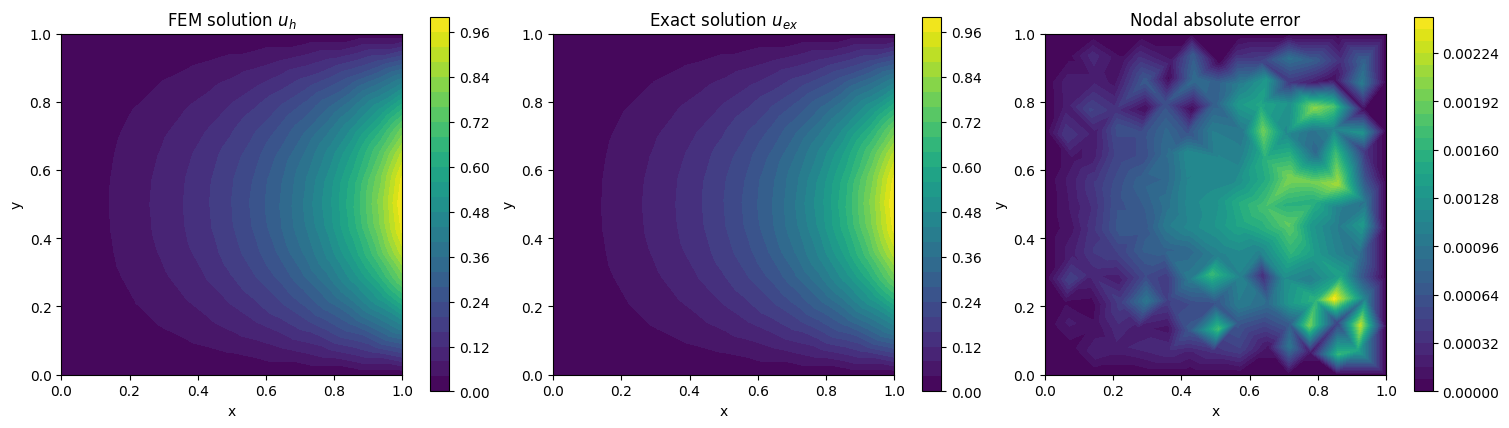

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

fields = [
    (u_h, r"FEM solution $u_h$"),
    (u_ex, r"Exact solution $u_{ex}$"),
    (np.abs(u_h - u_ex), r"Nodal absolute error"),
]

for ax, (field, title) in zip(axes, fields):
    im = ax.tricontourf(nodes[:, 0], nodes[:, 1], triangles, field, levels=30)
    fig.colorbar(im, ax=ax)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

plt.show()

In [10]:
np.abs(u_h - u_ex).mean()*100

np.float64(0.06093042949541378)

## 6. Error measured over the elements

A nodal error is easy to compute, but it is not the same thing as the continuous $L^2$ or $H^1$ error. Because the FEM solution is linear in each triangle, we can evaluate it at quadrature points using barycentric coordinates.

Below we use the standard three-point degree-2 quadrature rule on each triangle. We estimate

$$
\|u-u_h\|_{L^2(\Omega)}
\qquad\text{and}\qquad
|u-u_h|_{H^1(\Omega)}
=\|\nabla u-\nabla u_h\|_{L^2(\Omega)}.
$$

For a smooth solution and quasi-uniform $P_1$ meshes, one expects approximately second-order convergence in $L^2$ and first-order convergence in the $H^1$ seminorm.

In [7]:
# Three barycentric quadrature points, each with weight 1/3 of the triangle area.
BARY_Q = np.array([
    [2/3, 1/6, 1/6],
    [1/6, 2/3, 1/6],
    [1/6, 1/6, 2/3],
])


def fem_errors(nodes, triangles, u_h):
    l2_err_sq = 0.0
    h1_err_sq = 0.0
    l2_exact_sq = 0.0
    h1_exact_sq = 0.0

    for tri in triangles:
        xy = nodes[tri]
        uh_local = u_h[tri]
        area, grad_phi = element_geometry(xy)

        # FEM gradient is constant on a P1 element.
        grad_uh = uh_local @ grad_phi

        q_xy = BARY_Q @ xy
        q_uh = BARY_Q @ uh_local
        q_uex = exact_solution(q_xy)
        q_grad_ex = exact_gradient(q_xy)

        w = area / 3.0
        l2_err_sq += w * np.sum((q_uh - q_uex)**2)
        l2_exact_sq += w * np.sum(q_uex**2)
        h1_err_sq += w * np.sum(np.sum((q_grad_ex - grad_uh)**2, axis=1))
        h1_exact_sq += w * np.sum(np.sum(q_grad_ex**2, axis=1))

    return {
        "L2": np.sqrt(l2_err_sq),
        "H1_semi": np.sqrt(h1_err_sq),
        "rel_L2": np.sqrt(l2_err_sq / l2_exact_sq),
        "rel_H1_semi": np.sqrt(h1_err_sq / h1_exact_sq),
    }


errors = fem_errors(nodes, triangles, u_h)
for key, value in errors.items():
    print(f"{key:>12s}: {value:.4e}")

          L2: 1.8139e-03
     H1_semi: 1.4600e-01
      rel_L2: 6.4947e-03
 rel_H1_semi: 1.1628e-01


## 7. Mesh-refinement study

To make the approximation properties visible, solve the same problem on increasingly fine meshes. For the convergence study we use the regular, non-jittered version of the mesh so that $h=1/n$ has a clean interpretation.

         h    nodes       L2 error    H1 seminorm
    0.1667       49    8.31304e-03    3.24687e-01
    0.1000      121    3.05453e-03    1.96839e-01
    0.0625      289    1.20197e-03    1.23468e-01
    0.0417      625    5.35631e-04    8.24181e-02
    0.0278     1369    2.38342e-04    5.49770e-02
    0.0192     2809    1.14291e-04    3.80701e-02

empirical L2 rate      ~= 1.99
empirical H1-semi rate ~= 0.99


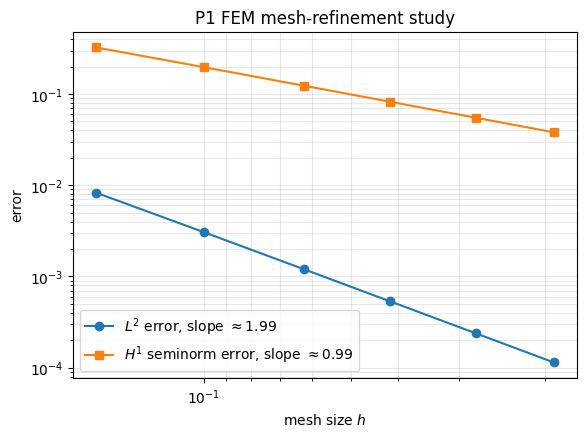

In [8]:
levels = [6, 10, 16, 24, 36, 52]
records = []

for n in levels:
    nodes_n, triangles_n = triangular_mesh(n=n, jitter=0.0)
    u_n, _ = solve_laplace(nodes_n, triangles_n)
    err = fem_errors(nodes_n, triangles_n, u_n)
    records.append((1.0 / n, len(nodes_n), err["L2"], err["H1_semi"]))

print(f"{'h':>10s} {'nodes':>8s} {'L2 error':>14s} {'H1 seminorm':>14s}")
for h, nn, e_l2, e_h1 in records:
    print(f"{h:10.4f} {nn:8d} {e_l2:14.5e} {e_h1:14.5e}")

h = np.array([r[0] for r in records])
e_l2 = np.array([r[2] for r in records])
e_h1 = np.array([r[3] for r in records])

rate_l2 = np.polyfit(np.log(h), np.log(e_l2), 1)[0]
rate_h1 = np.polyfit(np.log(h), np.log(e_h1), 1)[0]

print(f"\nempirical L2 rate      ~= {rate_l2:.2f}")
print(f"empirical H1-semi rate ~= {rate_h1:.2f}")

plt.figure(figsize=(6.5, 4.5))
plt.loglog(h, e_l2, "o-", label=fr"$L^2$ error, slope $\approx {rate_l2:.2f}$")
plt.loglog(h, e_h1, "s-", label=fr"$H^1$ seminorm error, slope $\approx {rate_h1:.2f}$")
plt.gca().invert_xaxis()
plt.xlabel(r"mesh size $h$")
plt.ylabel("error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("P1 FEM mesh-refinement study")
plt.show()

## 8. What to notice

- The PDE is never discretised by replacing $\Delta$ with a finite-difference stencil. Instead, the **weak bilinear form** is discretised.
- Geometry enters element-by-element through the Jacobian $J_T$.
- The $P_1$ basis has local support, so the assembled stiffness matrix is sparse.
- Non-homogeneous Dirichlet data enter through the coupling block $K_{IB}$.
- For this symmetric coercive Laplace problem, the Bubnov-Galerkin solution is also the Ritz minimiser of the discrete Dirichlet energy.
- With a smooth exact solution, the refinement study should approach the classical $P_1$ behaviour: $O(h^2)$ in $L^2$ and $O(h)$ in the $H^1$ seminorm.

## References

- S. Runser, *FEM from Scratch in Python*, GitHub repository: https://github.com/SteveRunser/FEM-from-scratch-python
- M. G. Larson and F. Bengzon, *The Finite Element Method: Theory, Implementation, and Applications*, Springer, 2013. DOI: 10.1007/978-3-642-33287-6.
- S. C. Brenner and L. R. Scott, *The Mathematical Theory of Finite Element Methods*, 3rd ed., Springer, 2008. DOI: 10.1007/978-0-387-75934-0.
